,Open,High,Low,Close,Volume
Date,,,,,
2024-06-11,173.92,174.750000,167.41,170.660000,64761900
2024-06-12,171.12,180.550000,169.80,177.289990,90389400
2024-06-13,188.39,191.080002,181.23,182.470000,118984100
2024-06-14,185.80,186.000000,176.92,178.009995,82038200
2024-06-17,177.92,188.810000,177.00,187.440000,109786100


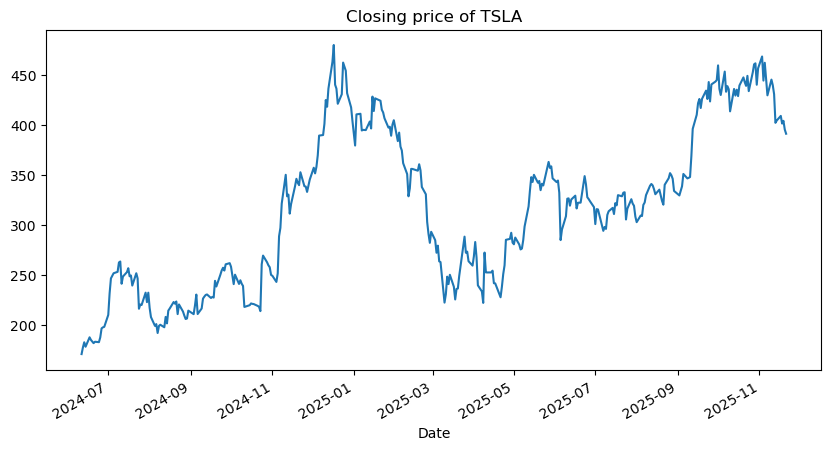

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

api_key = "INSERT_YOUR_API_KEY"

symbol = "TSLA"  

url = (
    f"https://api.twelvedata.com/time_series"
    f"?symbol={symbol}"
    f"&interval=1day"
    f"&outputsize=365"
    f"&apikey={api_key}"
)

response = requests.get(url)
data_json = response.json()

if "values" not in data_json:
    print("Erreur API :", data_json)
else:
    df = pd.DataFrame(data_json["values"])

    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime")

    df = df.rename(columns={
        "datetime": "Date",
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume"
    })

    df = df.set_index("Date")

    for col in ["Open", "High", "Low", "Close", "Volume"]:
        df[col] = pd.to_numeric(df[col])

    display(df.head())

    df["Close"].plot(figsize=(10,5), title=f"Closing price of {symbol}")
    plt.show()




In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2024-06-11 to 2025-11-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    365 non-null    float64
 1   High    365 non-null    float64
 2   Low     365 non-null    float64
 3   Close   365 non-null    float64
 4   Volume  365 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 17.1 KB


In [16]:
df.isna().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [17]:
df = df.dropna()


In [20]:
df["returns"] = df["Close"].pct_change()
display(df.head())


,Open,High,Low,Close,Volume,returns,MA20
Date,,,,,,,
2024-06-11,173.92,174.750000,167.41,170.660000,64761900,NaN,NaN
2024-06-12,171.12,180.550000,169.80,177.289990,90389400,0.038849,NaN
2024-06-13,188.39,191.080002,181.23,182.470000,118984100,0.029218,NaN
2024-06-14,185.80,186.000000,176.92,178.009995,82038200,-0.024442,NaN
2024-06-17,177.92,188.810000,177.00,187.440000,109786100,0.052975,NaN


In [21]:
df["MA20"] = df["Close"].rolling(20).mean()
display(df.head())


,Open,High,Low,Close,Volume,returns,MA20
Date,,,,,,,
2024-06-11,173.92,174.750000,167.41,170.660000,64761900,NaN,NaN
2024-06-12,171.12,180.550000,169.80,177.289990,90389400,0.038849,NaN
2024-06-13,188.39,191.080002,181.23,182.470000,118984100,0.029218,NaN
2024-06-14,185.80,186.000000,176.92,178.009995,82038200,-0.024442,NaN
2024-06-17,177.92,188.810000,177.00,187.440000,109786100,0.052975,NaN


In [22]:
display(df[["Close", "returns", "MA20"]].head(10))


,Close,returns,MA20
Date,,,
2024-06-11,170.660000,NaN,NaN
2024-06-12,177.289990,0.038849,NaN
2024-06-13,182.470000,0.029218,NaN
2024-06-14,178.009995,-0.024442,NaN
2024-06-17,187.440000,0.052975,NaN
2024-06-18,184.860000,-0.013764,NaN
2024-06-20,181.570010,-0.017797,NaN
2024-06-21,183.009995,0.007931,NaN
2024-06-24,182.580000,-0.002350,NaN


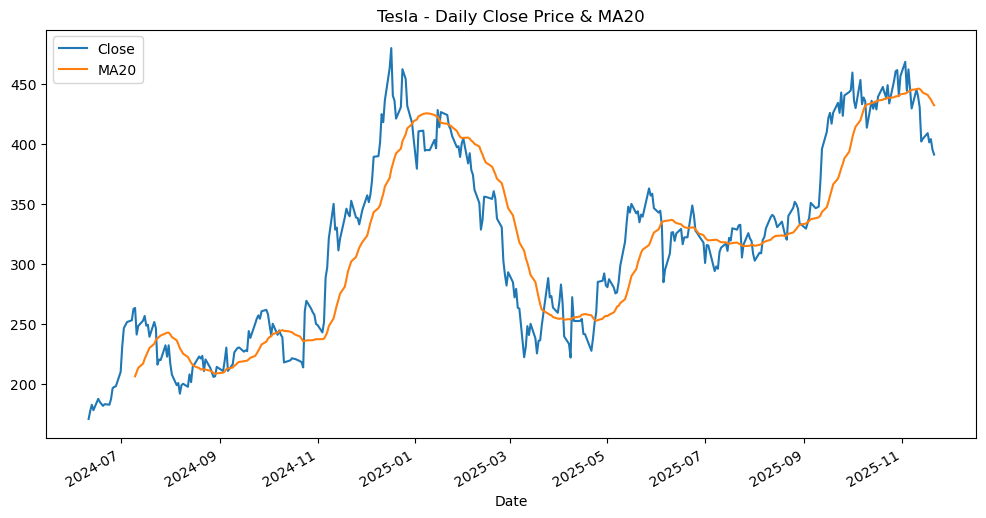

In [24]:
df["Close"].plot(figsize=(12,6), label="Close")
df["MA20"].plot(label="MA20")
plt.legend()
plt.title("Tesla - Daily Close Price & MA20")
plt.show()


In [26]:
df["absolute_returns"] = df["returns"].abs()

df_sorted = df.sort_values(by="absolute_returns", ascending=False)

df_sorted[["Close", "returns", "absolute_returns"]].head(10)



,Close,returns,absolute_returns
Date,,,
2025-04-09,272.20001,0.226900,0.226900
2024-10-24,260.48001,0.219190,0.219190
2025-03-10,222.14999,-0.154262,0.154262
2024-11-06,288.53000,0.147510,0.147510
2025-06-05,284.70001,-0.142599,0.142599
2024-07-24,215.99001,-0.123346,0.123346
2025-03-24,278.39001,0.119336,0.119336
2025-04-04,239.42999,-0.104198,0.104198
2024-07-02,231.25999,0.101973,0.101973


## Conclusion

The analysis shows several clear phases in Tesla's price movement over the period.
The stock trends upward from late 2024 to early 2025, followed by sharper corrections later on.

The 20-day moving average smooths out the noise and makes trend changes easier to see.
It highlights when momentum accelerates or slows down and gives a cleaner view of the overall direction.

Daily returns confirm that the asset went through multiple high-volatility periods.
Sorting absolute returns shows several days above ±10%, with extremes up to +22.7% and -15.4%.
These large swings suggest strong market reactions, likely driven by major announcements or macro events.

Overall, the asset shows a generally bullish trend with noticeable volatility spikes.
The indicators used (returns and MA20) help interpret both direction and instability in a simple way.
